## LangGraph Introduction and Basics

In [ ]:
from dotenv import load_dotenv

load_dotenv()

import os
print(os.environ['OPENAI_API_KEY'][:20])

## Simple non-AI graph example
Generate some random values, and sum them up.

In [1]:
import random
values = [random.randint(0, 10) for _ in range(10)]
print(f"Sum of values: {sum(values)}")

Sum of values: 52


In [2]:
# Define the state of the graph:
from typing import TypedDict

class State(TypedDict):
    num_values: int
    generated_values: list[int]
    result: int | None = None


In [4]:
import random

# Define the nodes in the graph:
def generate_values(state: State):
    values = [random.randint(0, 10) for _ in range(state["num_values"])]
    return {"generated_values": values}

def add(state: State):
    result = sum(state["generated_values"])
    return {"result": result}

In [5]:
# Define the graph:
from langgraph.graph import StateGraph
from langgraph.graph import START, END

graph_builder = StateGraph(State)
graph_builder.add_node("generate_values", generate_values)
graph_builder.add_node("add", add)

graph_builder.add_edge(START, "generate_values")
graph_builder.add_edge("generate_values", "add")
graph_builder.add_edge("add", END)

# Now graph is also a 'Runnable'
graph = graph_builder.compile()

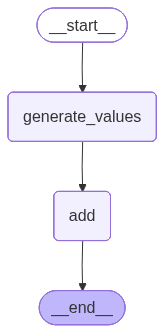

In [6]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [7]:
result = graph.invoke({"num_values": 10})

In [8]:
print(result)

{'num_values': 10, 'generated_values': [8, 0, 6, 9, 2, 9, 4, 2, 2, 3], 'result': 45}


In [9]:
await graph.ainvoke({"num_values": 10})

{'num_values': 10,
 'generated_values': [9, 0, 4, 5, 2, 3, 1, 6, 7, 7],
 'result': 44}

## Conditional Edge example in LangGraph

In [10]:
class ConditionalEdgeState(TypedDict):
    num_values: int
    generated_values: list[int]
    total: int
    # Prints happy if the total is even, sad if the total is odd
    final_message: str

def generate_values(state: ConditionalEdgeState):
    generated_values = [random.randint(0, 10) for _ in range(state["num_values"])]
    return {"generated_values": generated_values}

def add(state: ConditionalEdgeState):
    total = sum(state["generated_values"])
    return {"total": total}

def check_total(state: ConditionalEdgeState):
    if state["total"] % 2 == 0:
        return "happy_message"
    else:
        return "sad_message"
    
def happy_message(state: ConditionalEdgeState):
    return {"final_message": "happy"}

def sad_message(state: ConditionalEdgeState):
    return {"final_message": "sad"}

graph_builder = StateGraph(ConditionalEdgeState)

graph_builder.add_node("generate_values", generate_values)
graph_builder.add_node("add", add)
graph_builder.add_node("happy_message", happy_message)
graph_builder.add_node("sad_message", sad_message)

graph_builder.add_edge(START, "generate_values")
graph_builder.add_edge("generate_values", "add")
# THIS is the place where the condition is evaluated
graph_builder.add_conditional_edges(
    "add",
    check_total,
    {
        "happy_message": "happy_message",
        "sad_message": "sad_message",
    },
)
graph_builder.add_edge("happy_message", END)
graph_builder.add_edge("sad_message", END)

graph = graph_builder.compile()


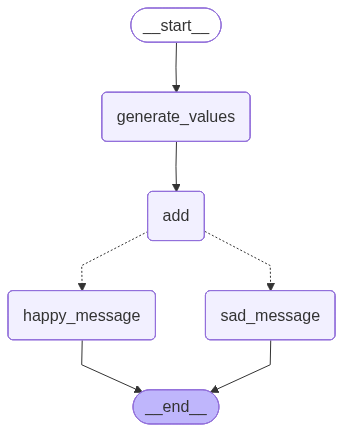

In [11]:
# Display the graph
display(Image(graph.get_graph().draw_mermaid_png()))

In [12]:
graph.invoke({"num_values": 10})

{'num_values': 10,
 'generated_values': [10, 9, 1, 5, 1, 0, 6, 5, 9, 2],
 'total': 48,
 'final_message': 'happy'}

## Using LangChain Components in LangGraph
A simple sentiment analyzer that branches to happy or sad responses.


In [13]:
# Import LangChain components
from langchain.chat_models import init_chat_model
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

# Initialize model and parser (can be used in LangGraph nodes!)
llm = init_chat_model("gemini-2.5-flash-lite", model_provider="google_genai")
parser = StrOutputParser()


In [14]:
# Define state
class SentimentState(TypedDict):
    sentence: str
    sentiment: str
    message: str

# Node: Analyze sentiment
def analyze_sentiment(state: SentimentState):
    prompt = ChatPromptTemplate.from_messages([
        ("system", "Analyze sentiment. Reply with ONLY 'happy' or 'sad'."),
        ("user", "{sentence}")
    ])
    chain = prompt | llm | parser
    sentiment = chain.invoke({"sentence": state["sentence"]}).strip().lower()
    return {"sentiment": sentiment}

# Node: Generate happy message
def happy_response(state: SentimentState):
    prompt = ChatPromptTemplate.from_messages([
        ("system", "Generate a cheerful, uplifting message in 1 sentence."),
        ("user", "The person said: {sentence}")
    ])
    chain = prompt | llm | parser
    message = chain.invoke({"sentence": state["sentence"]})
    return {"message": message}

# Node: Generate sad message
def sad_response(state: SentimentState):
    prompt = ChatPromptTemplate.from_messages([
        ("system", "Generate a comforting message in 1 sentence that says it's alright."),
        ("user", "The person said: {sentence}")
    ])
    chain = prompt | llm | parser
    message = chain.invoke({"sentence": state["sentence"]})
    return {"message": message}


In [15]:
# Routing function: returns a ROUTE KEY (string) to determine which path to take
def route_sentiment(state: SentimentState):
    if "happy" in state["sentiment"]:
        return "positive_route"  # Route key for positive sentiment
    else:
        return "negative_route"  # Route key for negative sentiment

# Build the graph
builder = StateGraph(SentimentState)
builder.add_node("analyze_sentiment", analyze_sentiment)
builder.add_node("happy_response", happy_response)
builder.add_node("sad_response", sad_response)

builder.add_edge(START, "analyze_sentiment")

# Conditional edges: map route keys to node names
builder.add_conditional_edges(
    "analyze_sentiment",  # Source node
    route_sentiment,      # Routing function that returns a route key
    {
        # If route key is "positive_route", go to node "happy_response"
        "positive_route": "happy_response",
        # If route key is "negative_route", go to node "sad_response"
        "negative_route": "sad_response"
    }
)
builder.add_edge("happy_response", END)
builder.add_edge("sad_response", END)

sentiment_graph = builder.compile()


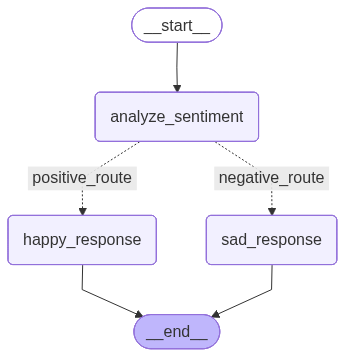

In [16]:
# Visualize the graph
display(Image(sentiment_graph.get_graph().draw_mermaid_png()))


In [17]:
# Example 1: Happy sentence
result = sentiment_graph.invoke({"sentence": "I got the job! I'm so excited!"})
print(f"Sentiment: {result['sentiment']}")
print(f"Message: {result['message']}")


Sentiment: happy
Message: Congratulations on landing your dream job; may it bring you immense joy and fulfillment!


In [18]:
# Example 2: Sad sentence
result = sentiment_graph.invoke({"sentence": "I failed my exam and feel terrible."})
print(f"Sentiment: {result['sentiment']}")
print(f"Message: {result['message']}")


Sentiment: sad
Message: It's okay, take a deep breath; this one setback doesn't define you.


## Why LangGraph then where I can do everything in LangChain?
- THE central framework from LangChain company.
- Less opinionated, more flexibility. Can still use LangChain within the nodes of a graph.
- Contains many primitives for building AI agents over the next few weeks.

### Tracing with Arize

In [20]:
import os
print(os.environ['OPENAI_API_KEY'][:10])
print(os.environ['ARIZE_API_KEY'][:10])
print(os.environ['ARIZE_SPACE_ID'][:10])

# Arize Imports
from arize.otel import register
from openinference.instrumentation.langchain import LangChainInstrumentor

# Register the project (this connects to Arize)
# 'project_name' creates a persistent project in your Arize dashboard
tracer_provider = register(
    space_id=os.environ["ARIZE_SPACE_ID"],
    api_key=os.environ["ARIZE_API_KEY"],
    project_name="langGraph-demo", 
)

# Instrument LangChain to send traces to the provider we just registered
LangChainInstrumentor(tracer_provider=tracer_provider).instrument()

print(f"Instrumentation active. Sending traces to Arize Cloud Project")

sk-proj-CA
ak-ca00d6b
U3BhY2U6ND
🔭 OpenTelemetry Tracing Details 🔭
|  Arize Project: langGraph-demo
|  Span Processor: BatchSpanProcessor
|  Collector Endpoint: otlp.arize.com
|  Transport: gRPC
|  Transport Headers: {'authorization': '****', 'api_key': '****', 'arize-space-id': '****', 'space_id': '****', 'arize-interface': '****'}
|  
|  Using a default SpanProcessor. `add_span_processor` will overwrite this default.
|  
|  `register` has set this TracerProvider as the global OpenTelemetry default.
|  To disable this behavior, call `register` with `set_global_tracer_provider=False`.

Instrumentation active. Sending traces to Arize Cloud Project


In [21]:
# Example 1: Happy sentence
result = sentiment_graph.invoke({"sentence": "I got the job! I'm so excited!"})
print(f"Sentiment: {result['sentiment']}")
print(f"Message: {result['message']}")

/home/haynescd/code/learn/problem_first_ai/.venv/lib/python3.11/site-packages/openinference/instrumentation/_spans.py:42: LangChainDeprecationWarning: Calling .text() as a method is deprecated. Use .text as a property instead (e.g., message.text).
  masked_value = self._self_config.mask(key, value)


Sentiment: happy
Message: Congratulations, that's absolutely wonderful news and I'm so happy for you!


In [22]:
# Example 2: Sad sentence
result = sentiment_graph.invoke({"sentence": "I failed my exam and feel terrible."})
print(f"Sentiment: {result['sentiment']}")
print(f"Message: {result['message']}")

Sentiment: sad
Message: It's alright, one exam doesn't define your worth or your future.
